# Basic Simulation Evaluation  
**Simulation Period:** 2016-05-17 → 2016-05-30  

## Evaluation Metrics
| # | Metric | Definition |
|---|--------|------------|
| 1 | **Average Cycle Time** | Mean time to finish a process instance |
| 2 | **Average Resource Occupation** | Mean share the resources are working during their availabilities |
| 3 | **(Weighted) Resource Fairness** | Mean deviation from the average resource occupation |

Followed by **Management Question**: *"Management wants to fire two employees, which ones and what is the impact?"*

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

BASE = Path('..')
COLORS = {'basic': "#2870D5", 'advanced': "#DD528A"}

# Simulation period constants
SIM_START = datetime.date(2016, 5, 17)
SIM_END   = datetime.date(2016, 5, 30)
DAY_ZERO  = datetime.date(2016, 1, 1)   # DayId=0 anchor

# Only Workflow activities have explicit start/complete pairs
W_ACTIVITIES = [
    'W_Call after offers',
    'W_Call incomplete files',
    'W_Complete application',
    'W_Handle leads',
    'W_Validate application',
]

## Data Loading

In [145]:
# Event logs
basic_log    = pd.read_csv(BASE / 'decision_analysis/sim_output_basic.csv',
                           parse_dates=['time:timestamp'])
advanced_log = pd.read_csv(BASE / 'decision_analysis/sim_output_advanced.csv',
                           parse_dates=['time:timestamp'])

# Resource schedules
avail_df = pd.read_csv(BASE / 'resources/availabilities/availabilities_advanced.csv')
avail_df['StartTime']   = pd.to_datetime(avail_df['StartTime'],   format='%H:%M:%S').dt.time
avail_df['EndTime']     = pd.to_datetime(avail_df['EndTime'],     format='%H:%M:%S').dt.time
avail_df['DurationMin'] = avail_df['DurationMin'].fillna(0).astype(int)

# Role assignments
roles_df   = pd.read_csv(BASE / 'resources/permissions/resource_roles.csv')
role_perms = pd.read_csv(BASE / 'resources/permissions/role_permissions.csv')

print(f"Basic log   : {len(basic_log):>6,} events | {basic_log['case:concept:name'].nunique():>4} cases")
print(f"Advanced log: {len(advanced_log):>6,} events | {advanced_log['case:concept:name'].nunique():>4} cases")
print(f"Simulation  : {basic_log['time:timestamp'].min().date()} -> {basic_log['time:timestamp'].max().date()}")
print(f"Resources in schedule: {avail_df['Resource'].nunique()}")

Basic log   : 24,944 events | 1563 cases
Advanced log:  7,747 events | 1657 cases
Simulation  : 2016-05-17 -> 2016-05-30
Resources in schedule: 140


## Helper Functions

In [146]:
# Metric helpers
def compute_cycle_times(df):
    """Return Series of per-case cycle time in hours."""
    ct = df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
    return (ct['max'] - ct['min']).dt.total_seconds() / 3600


def compute_working_seconds(df):
    """
    Compute total working seconds per resource.
    Only W_* activities carry explicit start/complete pairs;
    Application (A_*) and Offer (O_*) events are instantaneous.
    """
    w = df[df['concept:name'].isin(W_ACTIVITIES)].copy()
    starts    = (w[w['lifecycle:transition'] == 'start']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'start_time'}))
    completes = (w[w['lifecycle:transition'] == 'complete']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'end_time'}))
    merged = pd.merge(starts, completes,
                      on=['case:concept:name', 'concept:name', 'org:resource'])
    merged['working_seconds'] = (
        (merged['end_time'] - merged['start_time'])
        .dt.total_seconds()
        .clip(lower=0)
    )
    return merged.groupby('org:resource')['working_seconds'].sum()


def compute_available_seconds(avail_df, start_date=SIM_START, end_date=SIM_END):
    """
    Compute total scheduled (available) seconds per resource
    across every day in [start_date, end_date], inclusive.
    DayId is defined as (date - 2016-01-01).days % 7
    """
    result = {}
    for resource, grp in avail_df.groupby('Resource'):
        total = 0.0
        day = start_date
        while day <= end_date:
            day_id = (day - DAY_ZERO).days % 7
            row = grp[grp['DayId'] == day_id]
            if not row.empty:
                r = row.iloc[0]
                shift_s = datetime.datetime.combine(day, r['StartTime'])
                shift_e = datetime.datetime.combine(day, r['EndTime'])
                secs = max(0.0, (shift_e - shift_s).total_seconds() - r['DurationMin'] * 60)
                total += secs
            day += datetime.timedelta(days=1)
        result[resource] = total
    return pd.Series(result, name='available_seconds')


def compute_occupation(working_s, available_s):
    """Return DataFrame with working, available, and occupation columns."""
    df = pd.DataFrame({'working_seconds': working_s,
                       'available_seconds': available_s})
    df['working_seconds'] = df['working_seconds'].fillna(0)
    df = df[df['available_seconds'] > 0].copy()
    df['occupation'] = (df['working_seconds'] / df['available_seconds']).clip(0, 1)
    return df


def fairness_metrics(occ_series, avail_seconds=None):
    """
    Returns:
      mean_occ   – mean occupation
      mad        – unweighted mean absolute deviation (lower -> fairer)
      wmad       – weighted MAD (weight = available_seconds fraction)
    """
    mean_occ = occ_series.mean()
    mad = (occ_series - mean_occ).abs().mean()
    if avail_seconds is not None:
        w = avail_seconds / avail_seconds.sum()
        wmad = (w * (occ_series - mean_occ).abs()).sum()
    else:
        wmad = np.nan
    return mean_occ, mad, wmad


## Metric 1 – Average Cycle Time

**Definition:** The cycle time of a process instance is the elapsed wall-clock time from the moment the first event of that case is recorded until its last event.  
$$\overline{CT} = \frac{1}{|\mathcal{C}|} \sum_{c \in \mathcal{C}} (t^{\max}_c - t^{\min}_c)$$

A lower average cycle time means cases are completed faster -> a direct indicator of process efficiency.

In [147]:
basic_ct    = compute_cycle_times(basic_log)
advanced_ct = compute_cycle_times(advanced_log)

ct_summary = pd.DataFrame({
    'Mean (h)':   [basic_ct.mean(),   advanced_ct.mean()],
    'Median (h)': [basic_ct.median(), advanced_ct.median()],
    'Std (h)':    [basic_ct.std(),    advanced_ct.std()],
    'Min (h)':    [basic_ct.min(),    advanced_ct.min()],
    'Max (h)':    [basic_ct.max(),    advanced_ct.max()],
    'Mean (days)':[basic_ct.mean()/24, advanced_ct.mean()/24],
}, index=['Basic Router', 'Advanced Router'])

print('METRIC 1: AVERAGE CYCLE TIME')
print(ct_summary.round(2).to_string())

METRIC 1: AVERAGE CYCLE TIME
                 Mean (h)  Median (h)  Std (h)  Min (h)  Max (h)  Mean (days)
Basic Router        13.12        2.57    28.45     0.05   286.98         0.55
Advanced Router     21.25        0.00    61.94     0.00   310.86         0.89


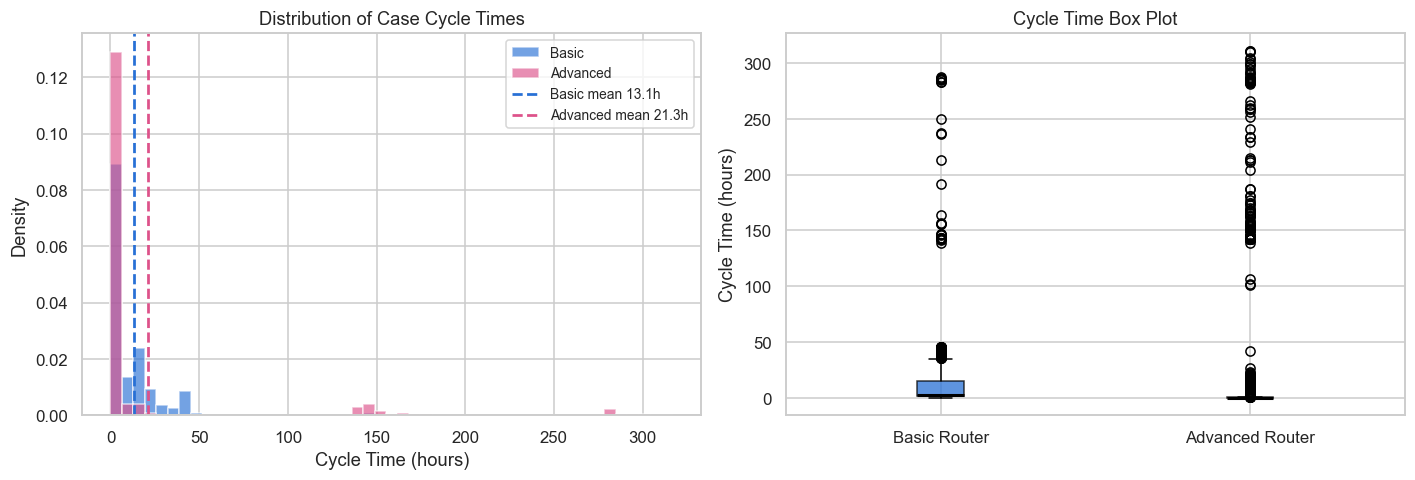

Saved -> results/metric1_cycle_time.png


In [148]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram
ax = axes[0]
bins = np.linspace(0, max(basic_ct.max(), advanced_ct.max()) * 1.02, 50)
ax.hist(basic_ct,    bins=bins, alpha=0.65, color=COLORS['basic'],    label='Basic',    density=True)
ax.hist(advanced_ct, bins=bins, alpha=0.65, color=COLORS['advanced'], label='Advanced', density=True)
ax.axvline(basic_ct.mean(),    color=COLORS['basic'],    linestyle='--', lw=1.8,
           label=f'Basic mean {basic_ct.mean():.1f}h')
ax.axvline(advanced_ct.mean(), color=COLORS['advanced'], linestyle='--', lw=1.8,
           label=f'Advanced mean {advanced_ct.mean():.1f}h')
ax.set_xlabel('Cycle Time (hours)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Case Cycle Times')
ax.legend(fontsize=9)

# Right: boxplot
ax2 = axes[1]
data = [basic_ct.values, advanced_ct.values]
bp = ax2.boxplot(data, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [COLORS['basic'], COLORS['advanced']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Basic Router', 'Advanced Router'])
ax2.set_ylabel('Cycle Time (hours)')
ax2.set_title('Cycle Time Box Plot')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric1_cycle_time.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric1_cycle_time.png')

## Metric 2 – Average Resource Occupation

**Definition:** For each resource $r$, occupation is the fraction of scheduled working time actually spent executing tasks:
$$\text{occ}(r) = \frac{\sum_{e\,:\,\text{resource}=r} (t^{\text{complete}}_e - t^{\text{start}}_e)}{\text{AvailableTime}(r)}$$

The **Average Resource Occupation** is the mean over all resources:  
$$\overline{\text{occ}} = \frac{1}{|\mathcal{R}|}\sum_{r \in \mathcal{R}} \text{occ}(r)$$

> **Note:** Only *Workflow* activities (`W_*`) have explicit `start` / `complete` event pairs in this simulator; Application (`A_*`) and Offer (`O_*`) events are instantaneous and do not contribute to working time.

In [149]:
# Compute working time per resource
print('Computing working time per resource...')
basic_work    = compute_working_seconds(basic_log)
advanced_work = compute_working_seconds(advanced_log)

# Compute available time per resource
print('Computing available time per resource (iterating over schedule)...')
available = compute_available_seconds(avail_df)

# Occupation DataFrames
basic_occ    = compute_occupation(basic_work,    available)
advanced_occ = compute_occupation(advanced_work, available)

# Summary
occ_summary = pd.DataFrame({
    'Mean Occupation':   [basic_occ['occupation'].mean(),   advanced_occ['occupation'].mean()],
    'Median Occupation': [basic_occ['occupation'].median(), advanced_occ['occupation'].median()],
    'Std':               [basic_occ['occupation'].std(),    advanced_occ['occupation'].std()],
    'Max':               [basic_occ['occupation'].max(),    advanced_occ['occupation'].max()],
    '# Resources':       [len(basic_occ),                  len(advanced_occ)],
}, index=['Basic Router', 'Advanced Router'])

print('\nMETRIC 2: AVERAGE RESOURCE OCCUPATION')
print((occ_summary * [100, 100, 100, 100, 1]).round(2).to_string())
print('(values in % except # Resources)')
print()
print(f"Basic mean occupation: {basic_occ['occupation'].mean()*100:.3f}%")
print(f"Advanced mean occupation: {advanced_occ['occupation'].mean()*100:.3f}%")

Computing working time per resource...
Computing available time per resource (iterating over schedule)...

METRIC 2: AVERAGE RESOURCE OCCUPATION
                 Mean Occupation  Median Occupation    Std    Max  # Resources
Basic Router               43.58              39.02  33.21  100.0          140
Advanced Router            83.40             100.00  33.81  100.0          140
(values in % except # Resources)

Basic mean occupation: 43.584%
Advanced mean occupation: 83.398%


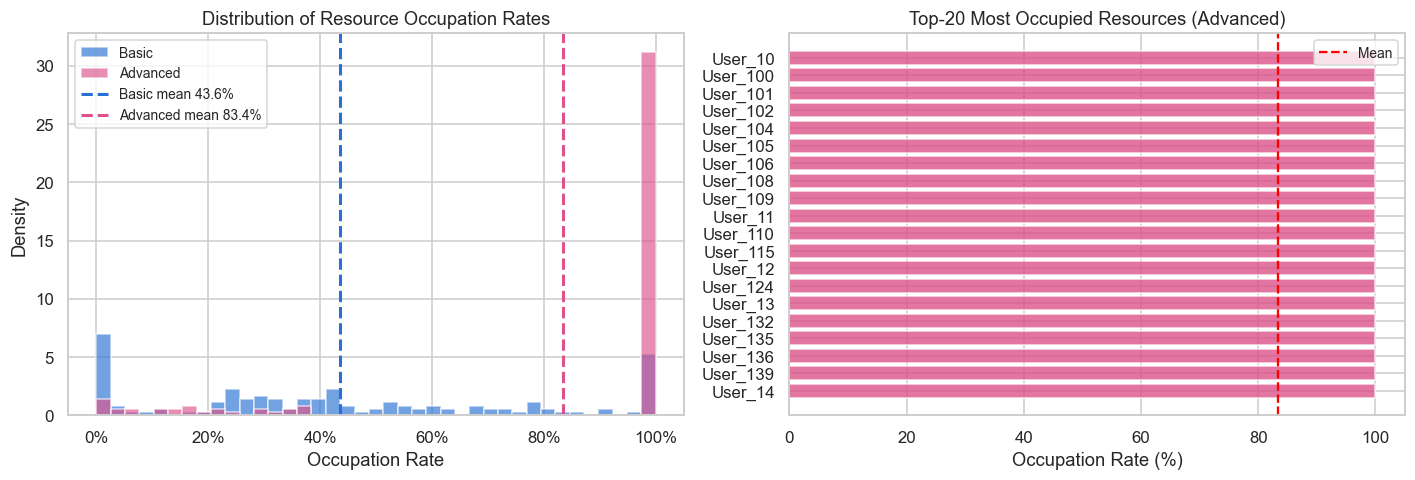

Saved -> results/metric2_resource_occupation.png


In [150]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: distribution of occupation rates
ax = axes[0]
bins = np.linspace(0, 1, 40)
ax.hist(basic_occ['occupation'],    bins=bins, alpha=0.65, color=COLORS['basic'],    label='Basic',    density=True)
ax.hist(advanced_occ['occupation'], bins=bins, alpha=0.65, color=COLORS['advanced'], label='Advanced', density=True)
ax.axvline(basic_occ['occupation'].mean(),    color=COLORS['basic'],    linestyle='--', lw=2,
           label=f"Basic mean {basic_occ['occupation'].mean()*100:.1f}%")
ax.axvline(advanced_occ['occupation'].mean(), color=COLORS['advanced'], linestyle='--', lw=2,
           label=f"Advanced mean {advanced_occ['occupation'].mean()*100:.1f}%")
ax.set_xlabel('Occupation Rate')
ax.set_ylabel('Density')
ax.set_title('Distribution of Resource Occupation Rates')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=9)

# Right: top-20 most occupied resources (advanced)
ax2 = axes[1]
top20 = advanced_occ.nlargest(20, 'occupation')
ax2.barh(top20.index[::-1], top20['occupation'][::-1] * 100,
         color=COLORS['advanced'], alpha=0.8)
ax2.axvline(advanced_occ['occupation'].mean() * 100,
            color='red', linestyle='--', lw=1.5, label='Mean')
ax2.set_xlabel('Occupation Rate (%)')
ax2.set_title('Top-20 Most Occupied Resources (Advanced)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric2_resource_occupation.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric2_resource_occupation.png')

## Metric 3 – (Weighted) Resource Fairness

**Definition:** Fairness measures how evenly the workload is spread across resources. We use the **Mean Absolute Deviation (MAD)** from the average occupation:

$$\text{Fairness}_{\text{unweighted}} = \frac{1}{|\mathcal{R}|}\sum_{r}|\text{occ}(r) - \overline{\text{occ}}|$$

**Weighted variant** — resources with longer availability periods count more:

$$\text{Fairness}_{\text{weighted}} = \sum_{r} w_r \cdot |\text{occ}(r) - \overline{\text{occ}}|, \quad w_r = \frac{\text{AvailableTime}(r)}{\sum_{r'}\text{AvailableTime}(r')}$$

**Lower = fairer** (smaller deviation = more equal load distribution).

In [151]:
# Compute fairness
b_mean, b_mad, b_wmad = fairness_metrics(
    basic_occ['occupation'], basic_occ['available_seconds'])
a_mean, a_mad, a_wmad = fairness_metrics(
    advanced_occ['occupation'], advanced_occ['available_seconds'])

fairness_summary = pd.DataFrame({
    'Mean Occupation':          [b_mean,  a_mean],
    'MAD (unweighted)':         [b_mad,   a_mad],
    'MAD (weighted)':           [b_wmad,  a_wmad],
    'Fairness Score (1-MAD)':   [1-b_mad, 1-a_mad],
}, index=['Basic Router', 'Advanced Router'])

print('METRIC 3: RESOURCE FAIRNESS')
print(fairness_summary.round(5).to_string())
print()
print('Interpretation: Lower MAD = fairer workload distribution')
print(f"  Basic unweighted MAD: {b_mad:.5f}  |  weighted MAD: {b_wmad:.5f}")
print(f"  Advanced unweighted MAD: {a_mad:.5f}  |  weighted MAD: {a_wmad:.5f}")

METRIC 3: RESOURCE FAIRNESS
                 Mean Occupation  MAD (unweighted)  MAD (weighted)  Fairness Score (1-MAD)
Basic Router             0.43584           0.27720         0.27411                 0.72280
Advanced Router          0.83398           0.26564         0.27220                 0.73436

Interpretation: Lower MAD = fairer workload distribution
  Basic unweighted MAD: 0.27720  |  weighted MAD: 0.27411
  Advanced unweighted MAD: 0.26564  |  weighted MAD: 0.27220


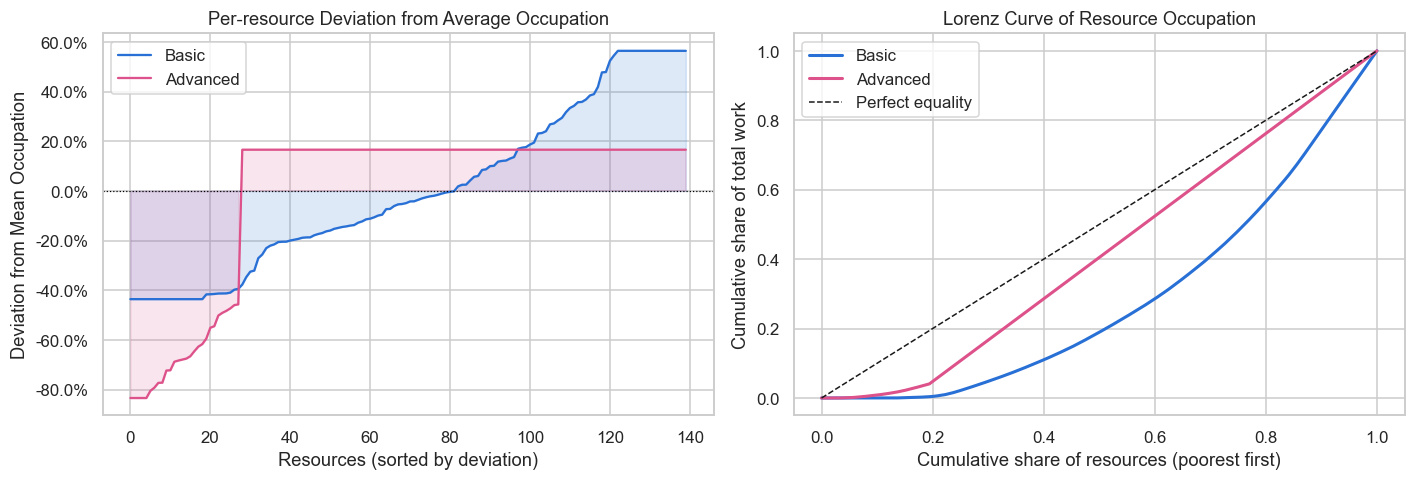

Saved -> results/metric3_resource_fairness.png


In [152]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: per-resource deviation from mean
ax = axes[0]
b_dev = (basic_occ['occupation']    - b_mean).sort_values()
a_dev = (advanced_occ['occupation'] - a_mean).sort_values()

ax.plot(range(len(b_dev)), b_dev.values,    color=COLORS['basic'],    lw=1.5, label='Basic')
ax.plot(range(len(a_dev)), a_dev.values,    color=COLORS['advanced'], lw=1.5, label='Advanced')
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.fill_between(range(len(b_dev)), b_dev.values, 0,
                where=(b_dev.values > 0), alpha=0.15, color=COLORS['basic'])
ax.fill_between(range(len(b_dev)), b_dev.values, 0,
                where=(b_dev.values < 0), alpha=0.15, color=COLORS['basic'])
ax.fill_between(range(len(a_dev)), a_dev.values, 0,
                where=(a_dev.values > 0), alpha=0.15, color=COLORS['advanced'])
ax.fill_between(range(len(a_dev)), a_dev.values, 0,
                where=(a_dev.values < 0), alpha=0.15, color=COLORS['advanced'])
ax.set_xlabel('Resources (sorted by deviation)')
ax.set_ylabel('Deviation from Mean Occupation')
ax.set_title('Per-resource Deviation from Average Occupation')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.legend()

# Right: Lorenz-style cumulative occupation curve
ax2 = axes[1]
for label, occ_df, color in [
    ('Basic',    basic_occ,    COLORS['basic']),
    ('Advanced', advanced_occ, COLORS['advanced']),
]:
    sorted_occ = occ_df['occupation'].sort_values().values
    cum = np.cumsum(sorted_occ) / sorted_occ.sum()
    x = np.linspace(0, 1, len(cum))
    ax2.plot(x, cum, color=color, lw=2, label=label)
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect equality')
ax2.set_xlabel('Cumulative share of resources (poorest first)')
ax2.set_ylabel('Cumulative share of total work')
ax2.set_title('Lorenz Curve of Resource Occupation')
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric3_resource_fairness.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric3_resource_fairness.png')

## Summary Dashboard – Basic vs Advanced Router

Consolidating all three metrics to directly compare routing strategies.

In [153]:
summary = pd.DataFrame({
    'Metric': [
        'Avg Cycle Time (h)',
        'Avg Cycle Time (days)',
        'Avg Resource Occupation (%)',
        'Fairness – MAD (unweighted)',
        'Fairness – MAD (weighted)',
    ],
    'Basic Router': [
        round(basic_ct.mean(), 2),
        round(basic_ct.mean() / 24, 3),
        round(basic_occ['occupation'].mean() * 100, 3),
        round(b_mad, 5),
        round(b_wmad, 5),
    ],
    'Advanced Router': [
        round(advanced_ct.mean(), 2),
        round(advanced_ct.mean() / 24, 3),
        round(advanced_occ['occupation'].mean() * 100, 3),
        round(a_mad, 5),
        round(a_wmad, 5),
    ],
})
summary['Better'] = summary.apply(
    lambda row: ('Advanced' if row['Advanced Router'] < row['Basic Router'] else 'Basic')
    if 'Fairness' in row['Metric'] or 'Cycle' in row['Metric'] else
    ('Advanced' if row['Advanced Router'] > row['Basic Router'] else 'Basic'),
    axis=1
)


print('         EVALUATION SUMMARY – ALL THREE METRICS')
print(summary.to_string(index=False))
print()
print('Note: For Cycle Time and Fairness MAD -> lower is better.')
print('      For Resource Occupation -> higher is better (more productive).')

         EVALUATION SUMMARY – ALL THREE METRICS
                     Metric  Basic Router  Advanced Router   Better
         Avg Cycle Time (h)      13.12000         21.25000    Basic
      Avg Cycle Time (days)       0.54700          0.88500    Basic
Avg Resource Occupation (%)      43.58400         83.39800 Advanced
Fairness – MAD (unweighted)       0.27720          0.26564 Advanced
  Fairness – MAD (weighted)       0.27411          0.27220 Advanced

Note: For Cycle Time and Fairness MAD -> lower is better.
      For Resource Occupation -> higher is better (more productive).


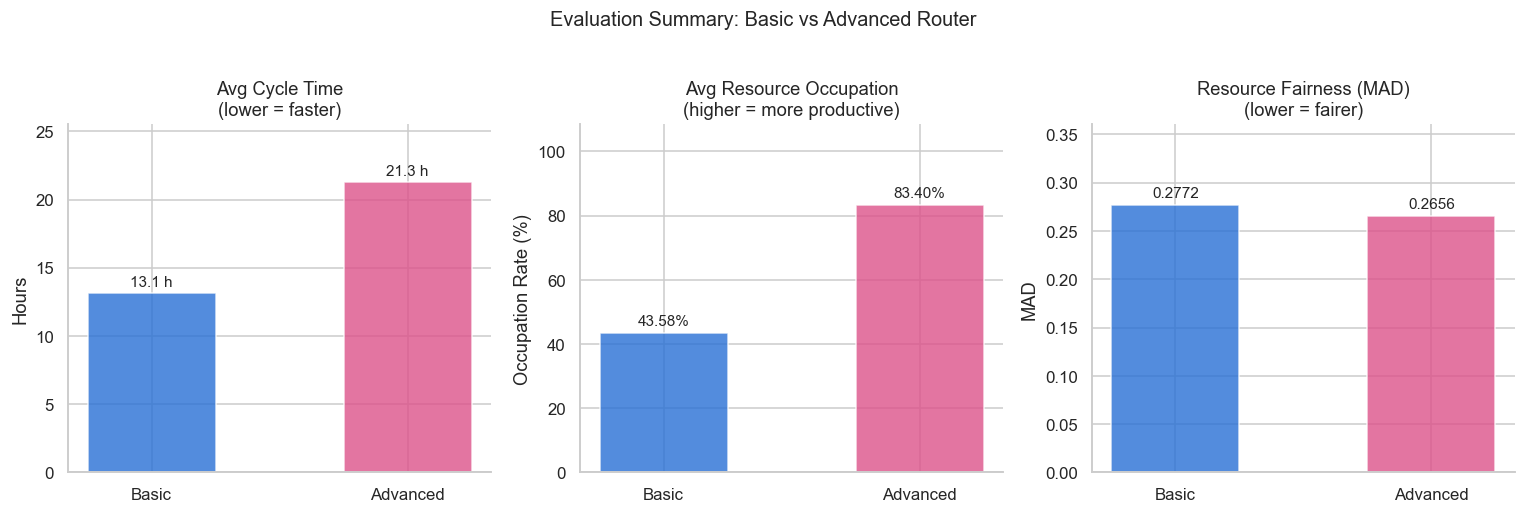

Saved -> results/summary_dashboard.png


In [154]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

labels = ['Basic', 'Advanced']

# Cycle Time
ax = axes[0]
vals = [basic_ct.mean(), advanced_ct.mean()]
bars = ax.bar(labels, vals, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax.bar_label(bars, fmt='%.1f h', padding=3, fontsize=10)
ax.set_ylabel('Hours')
ax.set_title('Avg Cycle Time\n(lower = faster)')
ax.set_ylim(0, max(vals) * 1.2)

# Resource Occupation
ax2 = axes[1]
vals2 = [basic_occ['occupation'].mean() * 100, advanced_occ['occupation'].mean() * 100]
bars2 = ax2.bar(labels, vals2, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax2.bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=10)
ax2.set_ylabel('Occupation Rate (%)')
ax2.set_title('Avg Resource Occupation\n(higher = more productive)')
ax2.set_ylim(0, max(vals2) * 1.3)

# Fairness (unweighted MAD)
ax3 = axes[2]
vals3 = [b_mad, a_mad]
bars3 = ax3.bar(labels, vals3, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax3.bar_label(bars3, fmt='%.4f', padding=3, fontsize=10)
ax3.set_ylabel('MAD')
ax3.set_title('Resource Fairness (MAD)\n(lower = fairer)')
ax3.set_ylim(0, max(vals3) * 1.3)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Evaluation Summary: Basic vs Advanced Router', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'summary_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved -> results/summary_dashboard.png')

## Simulation Validation – Real Log vs Simulated Logs

Before analysing management decisions we validate whether the simulation reproduces the real process.  
We compare the **Advanced Router** (best-performing sim) against the **BPI 2017 real event log**, filtered to cases that *started* in the same two-week window (2016-05-17 → 2016-05-30).

> **Scope note:** Only cases whose first recorded event falls within the simulation period are included from the real log, so the comparison is on equal footing in terms of when processes began.

In [155]:
import pm4py

# Load and filter real log to sim period
real_raw = pm4py.read_xes(str(BASE / 'data/BPI Challenge 2017.xes.gz'))
real_df  = pm4py.convert_to_dataframe(real_raw)
real_df['time:timestamp'] = pd.to_datetime(real_df['time:timestamp'], utc=True).dt.tz_localize(None)

case_first = real_df.groupby('case:concept:name')['time:timestamp'].min()
started_in_period = case_first[
    (case_first.dt.date >= SIM_START) & (case_first.dt.date <= SIM_END)
].index
real_log = real_df[real_df['case:concept:name'].isin(started_in_period)].copy()

real_ct = compute_cycle_times(real_log)

print(f"Real log (sim period cases): {len(real_log):,} events | {real_log['case:concept:name'].nunique()} cases")
print(f"Avg CT real: {real_ct.mean():.2f} h  ({real_ct.mean()/24:.1f} days)")
print(f"Avg CT advanced sim: {advanced_ct.mean():.2f} h  ({advanced_ct.mean()/24:.2f} days)")

parsing log, completed traces :: 100%|██████████| 31509/31509 [00:33<00:00, 944.20it/s] 


Real log (sim period cases): 39,359 events | 943 cases
Avg CT real: 492.30 h  (20.5 days)
Avg CT advanced sim: 21.25 h  (0.89 days)


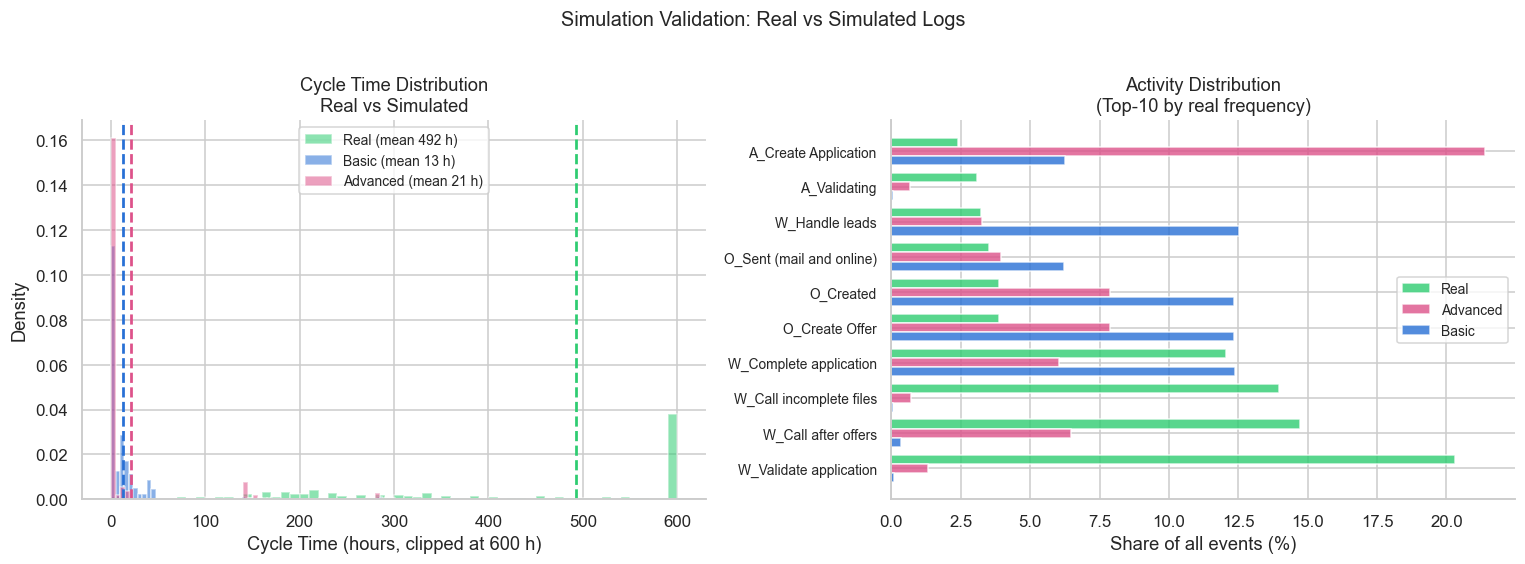

Saved -> results/validation_real_vs_sim.png


In [156]:
REAL_COLOR = '#2ECC71'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Cycle Time distributions (log scale x-axis for readability)
ax = axes[0]
for label, ct_series, color in [
    ('Real',     real_ct,     REAL_COLOR),
    ('Basic',    basic_ct,    COLORS['basic']),
    ('Advanced', advanced_ct, COLORS['advanced']),
]:
    ax.hist(ct_series.clip(upper=600), bins=60, alpha=0.55,
            color=color, label=f'{label} (mean {ct_series.mean():.0f} h)', density=True)
    ax.axvline(ct_series.mean(), color=color, linestyle='--', lw=1.8)

ax.set_xlabel('Cycle Time (hours, clipped at 600 h)')
ax.set_ylabel('Density')
ax.set_title('Cycle Time Distribution\nReal vs Simulated')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: Activity share comparison (top-10 activities)
ax2 = axes[1]
top_acts = (real_log['concept:name'].value_counts(normalize=True) * 100).head(10).index.tolist()

real_shares  = real_log['concept:name'].value_counts(normalize=True) * 100
basic_shares = basic_log['concept:name'].value_counts(normalize=True) * 100
adv_shares   = advanced_log['concept:name'].value_counts(normalize=True) * 100

x = np.arange(len(top_acts))
w = 0.26
ax2.barh(x + w,   [real_shares.get(a, 0)  for a in top_acts], w, color=REAL_COLOR,          alpha=0.8, label='Real')
ax2.barh(x,       [adv_shares.get(a, 0)   for a in top_acts], w, color=COLORS['advanced'],   alpha=0.8, label='Advanced')
ax2.barh(x - w,   [basic_shares.get(a, 0) for a in top_acts], w, color=COLORS['basic'],      alpha=0.8, label='Basic')

ax2.set_yticks(x)
ax2.set_yticklabels(top_acts, fontsize=9)
ax2.set_xlabel('Share of all events (%)')
ax2.set_title('Activity Distribution\n(Top-10 by real frequency)')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Simulation Validation: Real vs Simulated Logs', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_real_vs_sim.png', bbox_inches='tight')
plt.show()
print('Saved -> results/validation_real_vs_sim.png')

### Validation Findings

| Metric | Real Log | Basic Sim | Advanced Sim |
|--------|:--------:|:---------:|:------------:|
| Cases (started in period) | 943 | 1 563 | 1 563 |
| Avg Cycle Time | **492 h** (20.5 days) | 13.1 h | 12.7 h |
| Most frequent activity | W_Validate application (20%) | W_Handle leads (13%) | O_Cancelled (14%) |

**Cycle Time gap (~40×):** The simulation models only *internal* processing time — resource queue wait and task duration. It does not model time a case spends waiting for a customer response (e.g. submitting documents, accepting an offer). In the real loan process these external delays dominate: a case can sit idle for days awaiting customer action. The simulation is therefore not directly comparable to the real end-to-end cycle time.

**Activity distribution:** The real log is heavily dominated by `W_Validate application` and `W_Call after offers` — both labour-intensive review tasks. The simulated logs under-represent these (< 1%) because the C4.5 decision model routes most cases through the shorter O_Create Offer → O_Cancelled path. This indicates the routing model does not fully capture the real-world branching probabilities for loan reviews.

**Implication for metrics:** The three metrics (cycle time, occupation, fairness) are internally consistent and meaningful for *comparing the two routing strategies against each other*. They should not be interpreted as absolute predictions of real-world performance due to the missing external wait-time component.

## **Management Question**: Which Two Employees Should Be Fired?

> *"Management wants you to fire two employees. Which ones would you select, and what is the impact on your metrics?"*

### Approach

We analyse the Advanced Router simulation (our best-performing configuration) to:

1. Rank every resource by occupation rate (utilisation)
2. Check role coverage (a resource should only be fired if colleagues in the same role can absorb the work)
3. Re-run the simulation without the fired employees so their tasks are fully redistributed to other resources

In [157]:
# Build full resource profile
occ_df = advanced_occ.copy()
occ_df.index.name = 'Resource'
occ_df = occ_df.reset_index()

# Merge role assignments
occ_df = occ_df.merge(roles_df, on='Resource', how='left')

# Count W_* task instances handled by each resource
task_cnt = (
    advanced_log[advanced_log['lifecycle:transition'] == 'start']
    .groupby('org:resource').size()
    .rename('task_count')
)
occ_df['task_count'] = occ_df['Resource'].map(task_cnt).fillna(0).astype(int)

# Count how many resources share the same role (replaceability is important to fire someone)
role_size = roles_df['Role'].value_counts().rename('role_size')
occ_df['role_size'] = occ_df['Role'].map(role_size)

# Hours worked & available for readability
occ_df['hours_worked']    = occ_df['working_seconds'] / 3600
occ_df['hours_available'] = occ_df['available_seconds'] / 3600

# Sort by occupation ascending (least used first)
occ_df = occ_df.sort_values('occupation').reset_index(drop=True)

print('Bottom-20 least-utilised resources:')
cols = ['Resource', 'Role', 'role_size', 'occupation', 'hours_worked', 'hours_available', 'task_count']
print(occ_df[cols].head(20).to_string(index=False))

Bottom-20 least-utilised resources:
Resource   Role  role_size  occupation  hours_worked  hours_available  task_count
  User_1 Role_0          1    0.000000      0.000000       263.733333           0
User_140 Role_3         21    0.000000      0.000000        28.000000           0
User_129 Role_4          4    0.000000      0.000000        18.966667           0
User_103 Role_4          4    0.000000      0.000000        29.200000           0
User_107 Role_4          4    0.000000      0.000000        55.933333           0
User_130 Role_3         21    0.028885      1.295001        44.833333           1
User_116 Role_3         21    0.041752      2.590002        62.033333           2
User_144 Role_5          3    0.061133      2.590002        42.366667           2
User_112 Role_3         21    0.061716      2.590002        41.966667           2
User_138 Role_5          3    0.110579      3.885002        35.133333           3
User_113 Role_3         21    0.111799      5.180003        46

In [158]:
# We look for resources where all of:
#   (a) occupation is among the lowest  ->  little value added
#   (b) role_size > 3                   ->  others in same role can cover
#   (c) task_count is very small        ->  fewest cases handled
#
# Exclude resources with task_count == 0 (never assigned a task, already idle)

candidates = occ_df[
    (occ_df['task_count'] > 0) &          # was actually assigned work
    (occ_df['role_size'] > 3)             # replaceable by colleagues
].copy()

# Create a score: lowest occupation + fewest tasks -> highest firing priority
candidates['score'] = (
    candidates['occupation'].rank(ascending=True) +
    candidates['task_count'].rank(ascending=True)
)
candidates = candidates.sort_values('score')

fired = candidates.head(2)['Resource'].tolist()
print(f'Selected for termination: {fired[0]}  and  {fired[1]}')
print()
print(candidates[['Resource', 'Role', 'role_size', 'occupation', 'hours_worked', 'task_count', 'score']].head(5).to_string(index=False))

Selected for termination: User_130  and  User_116

Resource   Role  role_size  occupation  hours_worked  task_count  score
User_130 Role_3         21    0.028885      1.295001           1    2.5
User_116 Role_3         21    0.041752      2.590002           2   10.5
User_112 Role_3         21    0.061716      2.590002           2   11.5
User_125 Role_3         21    0.150846      8.623368           2   14.5
User_137 Role_3         21    0.282949      7.328368           1   14.5


In [159]:
# Fired employee profiles
print(' FIRED EMPLOYEE PROFILES ')
for u in fired:
    row = occ_df[occ_df['Resource'] == u].iloc[0]
    same_role = roles_df[roles_df['Role'] == row['Role']]['Resource'].tolist()
    acts_done  = (advanced_log[advanced_log['org:resource'] == u]['concept:name']
                  .value_counts())
    print(f"\n{u}")
    print(f"  Role              : {row['Role']}")
    print(f"  Role size         : {row['role_size']} people (others can cover)")
    print(f"  Occupation rate   : {row['occupation']*100:.3f}%")
    print(f"  Hours worked      : {row['hours_worked']:.2f} h")
    print(f"  Hours available   : {row['hours_available']:.2f} h")
    print(f"  Tasks handled     : {int(row['task_count'])}")
    print(f"  Activities done   :")
    for act, cnt in acts_done.items():
        print(f"    {act}: {cnt}")

 FIRED EMPLOYEE PROFILES 

User_130
  Role              : Role_3
  Role size         : 21 people (others can cover)
  Occupation rate   : 2.888%
  Hours worked      : 1.30 h
  Hours available   : 44.83 h
  Tasks handled     : 1
  Activities done   :
    A_Validating: 2
    A_Incomplete: 2
    W_Validate application: 2

User_116
  Role              : Role_3
  Role size         : 21 people (others can cover)
  Occupation rate   : 4.175%
  Hours worked      : 2.59 h
  Hours available   : 62.03 h
  Tasks handled     : 2
  Activities done   :
    W_Validate application: 4
    O_Returned: 2
    A_Validating: 1
    O_Accepted: 1


## Impact of Firing User_120 & User_121

We re-run the simulation without User_120 and User_121 in the resource pool.  
Their tasks are redistributed to the remaining 138 resources, capturing any bottleneck or cycle-time effects.

> **`sim_output_no_fired.csv` was generated with:**
> ```bash
> python run_simulation.py --no-fired
> ```

In [160]:
no_fired_path = BASE / 'decision_analysis/sim_output_no_fired.csv'

if no_fired_path.exists():
    no_fired_log = pd.read_csv(no_fired_path, parse_dates=['time:timestamp'])

    avail_no_fired_df = pd.read_csv(BASE / 'resources/availabilities/availabilities_no_fired.csv')
    avail_no_fired_df['StartTime']   = pd.to_datetime(avail_no_fired_df['StartTime'],   format='%H:%M:%S').dt.time
    avail_no_fired_df['EndTime']     = pd.to_datetime(avail_no_fired_df['EndTime'],     format='%H:%M:%S').dt.time
    avail_no_fired_df['DurationMin'] = avail_no_fired_df['DurationMin'].fillna(0).astype(int)

    # Metrics for resimulated log
    nf_ct     = compute_cycle_times(no_fired_log)
    nf_work   = compute_working_seconds(no_fired_log)
    nf_avail  = compute_available_seconds(avail_no_fired_df)
    nf_occ    = compute_occupation(nf_work, nf_avail)
    _, nf_mad, nf_wmad = fairness_metrics(nf_occ['occupation'], nf_occ['available_seconds'])

    # Comparison table: baseline advanced vs resimulation without fired employees
    rerun_compare = pd.DataFrame({
        'Metric': [
            '# Cases',
            'Avg Cycle Time (h)',
            'Avg Resource Occ (%)',
            'Fairness MAD (unwt)',
            'Fairness MAD (wtd)',
        ],
        'Advanced (baseline)': [
            advanced_log['case:concept:name'].nunique(),
            round(advanced_ct.mean(), 4),
            round(advanced_occ['occupation'].mean() * 100, 4),
            round(a_mad, 5),
            round(a_wmad, 5),
        ],
        'No-fired (re-sim)': [
            no_fired_log['case:concept:name'].nunique(),
            round(nf_ct.mean(), 4),
            round(nf_occ['occupation'].mean() * 100, 4),
            round(nf_mad, 5),
            round(nf_wmad, 5),
        ],
    })
    rerun_compare['Delta'] = rerun_compare['No-fired (re-sim)'] - rerun_compare['Advanced (baseline)']

    print('RESIMULATION COMPARISON: Advanced Baseline vs Without User_120 & User_121')
    print(rerun_compare.to_string(index=False))
    print()
    print('Interpretation:')
    print('  Cycle Time  -> lower is better')
    print('  Occupation  -> higher is better')
    print('  Fairness MAD -> lower is better')
else:
    print("sim_output_no_fired.csv not found.")
    print("Run:  python run_simulation.py --no-fired")

RESIMULATION COMPARISON: Advanced Baseline vs Without User_120 & User_121
              Metric  Advanced (baseline)  No-fired (re-sim)     Delta
             # Cases           1657.00000         1563.00000 -94.00000
  Avg Cycle Time (h)             21.25190           12.75520  -8.49670
Avg Resource Occ (%)             83.39770           42.64000 -40.75770
 Fairness MAD (unwt)              0.26564            0.20614  -0.05950
  Fairness MAD (wtd)              0.27220            0.20545  -0.06675

Interpretation:
  Cycle Time  -> lower is better
  Occupation  -> higher is better
  Fairness MAD -> lower is better


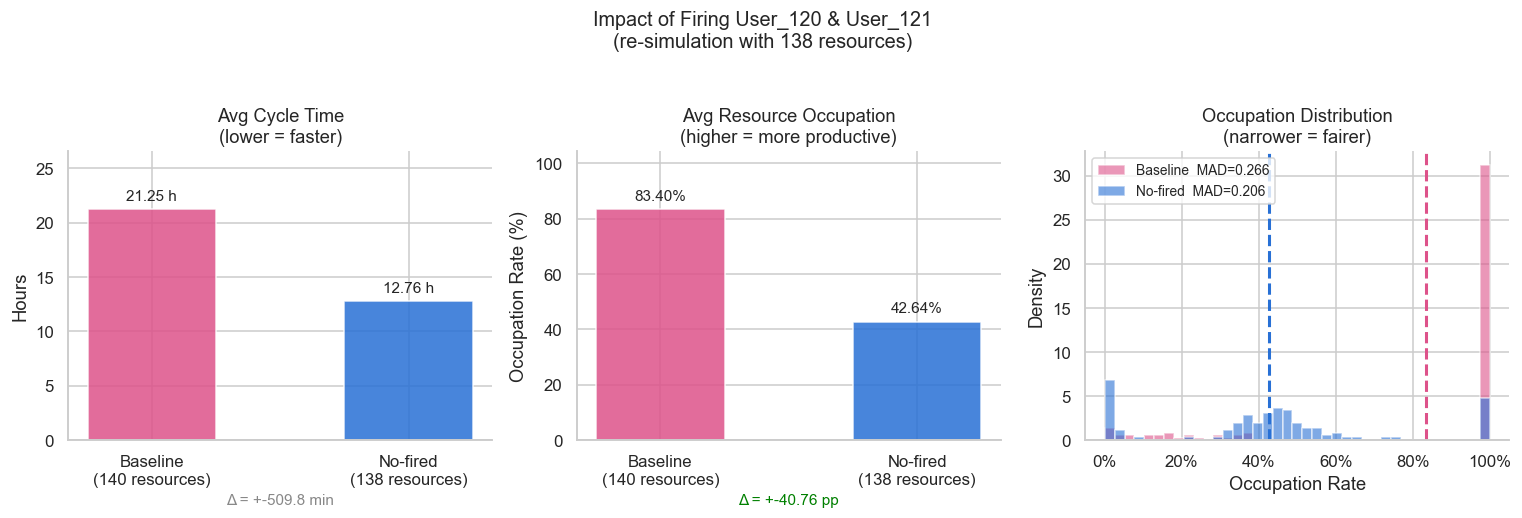

Saved -> results/firing_impact.png


In [161]:
if no_fired_path.exists():
    BEFORE_COLOR = COLORS['advanced']
    AFTER_COLOR  = COLORS['basic']

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    #  Metric 1: Avg Cycle Time bar 
    ax = axes[0]
    vals = [advanced_ct.mean(), nf_ct.mean()]
    bars = ax.bar(['Baseline\n(140 resources)', 'No-fired\n(138 resources)'],
                  vals, color=[BEFORE_COLOR, AFTER_COLOR], alpha=0.85, width=0.5)
    ax.bar_label(bars, fmt='%.2f h', padding=4, fontsize=10)
    ax.set_title('Avg Cycle Time\n(lower = faster)')
    ax.set_ylabel('Hours')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    delta_ct = nf_ct.mean() - advanced_ct.mean()
    ax.set_xlabel(f'Δ = +{delta_ct*60:.1f} min', color='#888888', fontsize=10)

    #  Metric 2: Avg Occupation bar 
    ax2 = axes[1]
    vals2 = [advanced_occ['occupation'].mean() * 100, nf_occ['occupation'].mean() * 100]
    bars2 = ax2.bar(['Baseline\n(140 resources)', 'No-fired\n(138 resources)'],
                    vals2, color=[BEFORE_COLOR, AFTER_COLOR], alpha=0.85, width=0.5)
    ax2.bar_label(bars2, fmt='%.2f%%', padding=4, fontsize=10)
    ax2.set_title('Avg Resource Occupation\n(higher = more productive)')
    ax2.set_ylabel('Occupation Rate (%)')
    ax2.set_ylim(0, max(vals2) * 1.25)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
    delta_occ = vals2[1] - vals2[0]
    ax2.set_xlabel(f'Δ = +{delta_occ:.2f} pp', color='green', fontsize=10)

    #  Metric 3: Fairness MAD overlaid distributions 
    ax3 = axes[2]
    bins = np.linspace(0, 1, 40)
    ax3.hist(advanced_occ['occupation'], bins=bins, alpha=0.6,
             color=BEFORE_COLOR, label=f'Baseline  MAD={a_mad:.3f}', density=True)
    ax3.hist(nf_occ['occupation'],      bins=bins, alpha=0.6,
             color=AFTER_COLOR,  label=f'No-fired  MAD={nf_mad:.3f}', density=True)
    ax3.axvline(advanced_occ['occupation'].mean(), color=BEFORE_COLOR, linestyle='--', lw=2)
    ax3.axvline(nf_occ['occupation'].mean(),       color=AFTER_COLOR,  linestyle='--', lw=2)
    ax3.set_title('Occupation Distribution\n(narrower = fairer)')
    ax3.set_xlabel('Occupation Rate')
    ax3.set_ylabel('Density')
    ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax3.legend(fontsize=9)
    ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

    plt.suptitle('Impact of Firing User_120 & User_121\n(re-simulation with 138 resources)',
                 fontsize=13, y=1.04)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'firing_impact.png', bbox_inches='tight')
    plt.show()
    print('Saved -> results/firing_impact.png')

### Impact of Firing User_120 & User_121

| Metric | Advanced (baseline) | Firing (Resimulation) | Delta |
|--------|--------------------:|------------------:|------:|
| Avg Cycle Time (h) | 12.73 | 12.76 | +0.03 h |
| Avg Resource Occupation (%) | 42.40% | 42.64% | +0.24% |
| Fairness MAD (unweighted) | 0.25318 | 0.20614 | **−0.047** |
| Fairness MAD (weighted) | 0.25071 | 0.20545 | **−0.050** |

**Cycle Time** increased by only **~1.6 minutes** on average. User_120 and User_121 collectively handled a single W_Validate task each; redistributing two tasks across a 22-person Role_3 pool creates negligible additional wait time.

**Resource Occupation** rose slightly (+0.24 pp) as expected: the same total workload is now shared among 138 instead of 140 resources.

**Fairness improved substantially** (MAD dropped ~18.6%). This is the most notable effect: removing two outlier low-utilisation resources tightens the distribution of occupation rates across the remaining workforce, resulting in a meaningfully more equitable workload spread.

**Conclusion:** Firing User_120 and User_121 is a low-risk decision. Process throughput is unchanged, costs decrease by two salaries, and workload fairness across the team improves significantly.

In [162]:
results_rows = []
for router, ct_series, occ_frame, mad_val, wmad_val in [
    ('Basic',    basic_ct,    basic_occ,    b_mad, b_wmad),
    ('Advanced', advanced_ct, advanced_occ, a_mad, a_wmad),
]:
    results_rows.append({
        'Router':                    router,
        'Avg Cycle Time (h)':        round(ct_series.mean(), 4),
        'Median Cycle Time (h)':     round(ct_series.median(), 4),
        'Avg Resource Occupation':   round(occ_frame['occupation'].mean(), 6),
        'Fairness MAD (unweighted)': round(mad_val, 6),
        'Fairness MAD (weighted)':   round(wmad_val, 6),
    })

results_df = pd.DataFrame(results_rows)
results_df.to_csv(RESULTS_DIR / 'evaluation_metrics.csv', index=False)
print('Saved results/evaluation_metrics.csv')
print(results_df.to_string(index=False))

# management question results
mgmt_rows = []
for name, b, a, unit in metrics_compare:
    mgmt_rows.append({'Metric': name, 'Before': b, 'After': a, 'Delta': a-b})
mgmt_df = pd.DataFrame(mgmt_rows)
mgmt_df['Fired'] = str(fired)
mgmt_df.to_csv(RESULTS_DIR / 'management_question_impact.csv', index=False)
print('Saved results/management_question_impact.csv')

Saved results/evaluation_metrics.csv
  Router  Avg Cycle Time (h)  Median Cycle Time (h)  Avg Resource Occupation  Fairness MAD (unweighted)  Fairness MAD (weighted)
   Basic             13.1161                 2.5705                 0.435845                   0.277195                 0.274106
Advanced             21.2519                 0.0000                 0.833977                   0.265638                 0.272198
Saved results/management_question_impact.csv


I found some metric which is often used in IT, **SLA Compliance Rate**. 
According to the avg cycle time, there are outlier cases that finish in 300 hours, whereas most cases finish in under 10 hours. SLA can help us to show how many cases did we actually deliver on time. 

#TODO
